In [1]:
# %% Cell 0: Profiling (optional) and Imports
# %load_ext line_profiler # If you want to use %lprun for specific functions
# %load_ext memory_profiler # If you want to use %memit

# Use %%prun at the top of a cell you want to profile with cProfile
# Example:
# %%prun -s cumulative -q -l 15 -T profile_results.txt 
# (This would profile the entire cell's execution)

import os
import numpy as np
import matplotlib.pyplot as plt
import sys
import logging # Good to have for messages from utils
from typing import Optional

# --- Add Project Root to sys.path ---
NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR) 
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print(f"Added project root to sys.path: {PROJECT_ROOT}")

# --- Import Custom Modules ---
from src.config_loader import MDetectorConfigAccessor # MODIFIED: Import accessor
from src.utils.validation_utils import (
    calculate_metrics_for_experiment_hdf5,    
    generate_roc_pr_data_gt_velocity_variant_hdf5, 
    load_config_from_hdf5 # Useful if you need to inspect a specific run's config
)
from src.visualization.metrics_plots import plot_roc_curve, plot_precision_recall_curve
from src.core.constants import OcclusionResult # For OcclusionResult.OCCLUDING_IMAGE.value

print("Cell 0: Imports and Paths - OK")

# %% Cell 1: Configuration and Path Setup

# --- Load Configuration using Accessor --- # MODIFIED
config_accessor: Optional[MDetectorConfigAccessor] = None
try:
    config_file_path = os.path.join(PROJECT_ROOT, 'config/m_detector_config.yaml')
    config_accessor = MDetectorConfigAccessor(config_file_path)
    print(f"Configuration loaded successfully using MDetectorConfigAccessor from: {config_file_path}")
except FileNotFoundError:
    print(f"ERROR: Config file not found at {config_file_path}. Cannot load default paths.")
except Exception as e:
    print(f"Error loading config with MDetectorConfigAccessor: {e}. Cannot load default paths.")

# --- Define Paths for GT Labels and M-Detector Outputs (HDF5) ---
# Use paths from config accessor as defaults, allow override if needed
default_gt_labels_dir = None
default_mdet_results_dir = None

if config_accessor:
    nuscenes_params = config_accessor.get_nuscenes_params()
    default_gt_labels_dir = nuscenes_params.get('label_path')
    if default_gt_labels_dir and not os.path.isabs(default_gt_labels_dir):
        default_gt_labels_dir = os.path.join(PROJECT_ROOT, default_gt_labels_dir)

    mdet_output_paths = config_accessor.get_mdetector_output_paths()
    default_mdet_results_dir = mdet_output_paths.get('save_path')
    if default_mdet_results_dir and not os.path.isabs(default_mdet_results_dir):
        default_mdet_results_dir = os.path.join(PROJECT_ROOT, default_mdet_results_dir)

# --- User-defined paths (can override defaults from config) ---
# These are the paths that will actually be used.
# If you want to use the config defaults, ensure these variables point to default_..._dir
# or that the hardcoded paths match your desired experimental output.

# Path to the directory containing your GT HDF5 files (e.g., gt_point_labels_scene-XXXX.h5)
GT_LABELS_BASE_DIR_HDF5 = default_gt_labels_dir if default_gt_labels_dir else "/home/drugge/staff-umbrella/TeamHolgerResearch/drugge/nuscenes_labels_interpolated_mini_test" # Fallback if not in config

# Path to the root directory of your M-Detector experiment results (containing scene-named HDF5 files like mdet_results_scene-XXXX.h5)
MDET_EXPERIMENT_DIR_HDF5 = default_mdet_results_dir if default_mdet_results_dir else "/home/drugge/staff-umbrella/TeamHolgerResearch/drugge/m_detector_output_mini_test" # Fallback

print(f"\nUsing M-Detector HDF5 Results From: {MDET_EXPERIMENT_DIR_HDF5}")
print(f"Using GT HDF5 Labels From:          {GT_LABELS_BASE_DIR_HDF5}")

if not os.path.isdir(MDET_EXPERIMENT_DIR_HDF5):
    print(f"WARNING: M-Detector results directory does not exist: {MDET_EXPERIMENT_DIR_HDF5}")
if not os.path.isdir(GT_LABELS_BASE_DIR_HDF5):
    print(f"WARNING: GT labels directory does not exist: {GT_LABELS_BASE_DIR_HDF5}")


# --- Base Evaluation Parameters ---
# These parameters define how the comparison between GT and M-Detector results is made.
base_eval_params = {
    "mdet_label_field_name": "mdet_label", # Field in MDet HDF5 holding the predicted label
    "mdet_dynamic_label_value": OcclusionResult.OCCLUDING_IMAGE.value, # Value indicating "dynamic" by MDet
    "coordinate_tolerance_for_verification": 1e-3, # Tolerance for matching points by coordinates
    
    # Default range parameters for filtering points before metric calculation.
    # These can be overridden if a scene's HDF5 M-Detector result file contains
    # its own run-specific config (which calculate_metrics_for_experiment_hdf5 tries to load).
    "mdet_min_point_range_meters": 1.0, # Fallback min range
    "mdet_max_point_range_meters": 50.0, # Fallback max range (matches your config)
}
# If you want to ensure these fallbacks also come from config:
if config_accessor:
    point_filter_params = config_accessor.get_point_pre_filtering_params()
    base_eval_params["mdet_min_point_range_meters"] = point_filter_params.get('min_range_meters', base_eval_params["mdet_min_point_range_meters"])
    base_eval_params["mdet_max_point_range_meters"] = point_filter_params.get('max_range_meters', base_eval_params["mdet_max_point_range_meters"])

print(f"\nBase Evaluation Parameters:")
for key, value in base_eval_params.items():
    print(f"  {key}: {value}")

print("\nCell 1: Configuration - OK")


Added project root to sys.path: /home/drugge/Unsupervised-Moving-Point-Detection/m_detector_python
Cell 0: Imports and Paths - OK
Configuration loaded successfully using MDetectorConfigAccessor from: /home/drugge/Unsupervised-Moving-Point-Detection/m_detector_python/config/m_detector_config.yaml

Using M-Detector HDF5 Results From: /home/drugge/staff-umbrella/TeamHolgerResearch/drugge/m_detector_output
Using GT HDF5 Labels From:          /home/drugge/staff-umbrella/TeamHolgerResearch/drugge/nuscenes_labels_interpolated

Base Evaluation Parameters:
  mdet_label_field_name: mdet_label
  mdet_dynamic_label_value: 0
  coordinate_tolerance_for_verification: 0.001
  mdet_min_point_range_meters: 2.5
  mdet_max_point_range_meters: 50.0

Cell 1: Configuration - OK


In [2]:


# %% Cell 2: Calculate Overall Summary Metrics 

# --- Parameters for this specific summary calculation ---
eval_params_for_summary = base_eval_params.copy()
# Define the GT velocity threshold to consider a GT point "truly dynamic" for this summary.
eval_params_for_summary["gt_velocity_threshold"] = 1.0 # m/s 

print(f"\nCalculating overall metrics with GT Velocity Threshold = {eval_params_for_summary['gt_velocity_threshold']:.2f} m/s...")

experiment_summary_hdf5 = calculate_metrics_for_experiment_hdf5( 
    mdet_experiment_dir=MDET_EXPERIMENT_DIR_HDF5,
    gt_labels_base_dir=GT_LABELS_BASE_DIR_HDF5,
    eval_params=eval_params_for_summary # Pass the combined and specific eval params
)

if experiment_summary_hdf5:
    print(f"\n--- Experiment Summary Metrics (HDF5, GT Vel Thresh = {eval_params_for_summary['gt_velocity_threshold']:.2f} m/s) ---")
    print(f"  File Format Used: {experiment_summary_hdf5.get('file_format_used', 'N/A')}")
    print(f"  Precision: {experiment_summary_hdf5.get('Precision', float('nan')):.4f}")
    print(f"  Recall:    {experiment_summary_hdf5.get('Recall', float('nan')):.4f}")
    print(f"  F1 Score:  {experiment_summary_hdf5.get('F1', float('nan')):.4f}")
    print(f"  IoU Dynamic: {experiment_summary_hdf5.get('overall_iou_dynamic', float('nan')):.4f}")
    print(f"  Accuracy:  {experiment_summary_hdf5.get('Accuracy', float('nan')):.4f}")
    print(f"  True Positives (Dynamic): {experiment_summary_hdf5.get('TP', 0)}")
    print(f"  False Positives (Dynamic): {experiment_summary_hdf5.get('FP', 0)}")
    print(f"  False Negatives (Dynamic): {experiment_summary_hdf5.get('FN', 0)}")
    print(f"  True Negatives (Static/Other): {experiment_summary_hdf5.get('TN', 0)}")
    print(f"  Scenes Evaluated: {experiment_summary_hdf5.get('num_scenes_successfully_evaluated', 0)}/{experiment_summary_hdf5.get('num_scenes_total_in_dir', 0)}")
    if experiment_summary_hdf5.get('scenes_with_errors', 0) > 0:
        print(f"  Scenes with errors: {experiment_summary_hdf5.get('scenes_with_errors')}")
        # Consider printing which scenes had errors if the helper returns that info
else:
    print("Failed to get experiment summary using HDF5 files.")

print("\nCell 2: Summary Metrics - OK")




Calculating overall metrics with GT Velocity Threshold = 1.00 m/s...


  Scenes (HDF5):   0%|          | 0/1 [00:00<?, ?it/s]

  Scenes (HDF5): 100%|██████████| 1/1 [00:43<00:00, 43.80s/it]


--- Experiment Summary Metrics (HDF5, GT Vel Thresh = 1.00 m/s) ---
  File Format Used: hdf5
  Precision: 0.6707
  Recall:    0.4408
  F1 Score:  0.5320
  IoU Dynamic: 0.3624
  Accuracy:  0.9887
  True Positives (Dynamic): 61792
  False Positives (Dynamic): 30343
  False Negatives (Dynamic): 78389
  True Negatives (Static/Other): 9447907
  Scenes Evaluated: 1/1

Cell 2: Summary Metrics - OK


In [3]:
import matplotlib.pyplot as plt
import numpy as np # For generating a range of threshold values

# %% Cell 2: Calculate and Plot Summary Metrics vs. GT Velocity Threshold

# --- Base Parameters ---
# Assuming base_eval_params is defined elsewhere in your notebook
# For example:
# base_eval_params = {
# "some_other_param": "value",
# # ... other base parameters
# }

# Assuming MDET_EXPERIMENT_DIR_HDF5 and GT_LABELS_BASE_DIR_HDF5 are defined
# For example:
# MDET_EXPERIMENT_DIR_HDF5 = "path/to/mdet_experiment_dir"
# GT_LABELS_BASE_DIR_HDF5 = "path/to/gt_labels_base_dir"


# --- Define the range of GT velocity thresholds to evaluate ---
# You can adjust the start, stop, and step as needed.
# np.linspace is good for a fixed number of points.
# np.arange is good for a fixed step size.
gt_velocity_thresholds = np.linspace(0.5, 5.0, 19)  
# Or, for specific steps:
# gt_velocity_thresholds = np.arange(0.1, 2.1, 0.1) # Example: 0.1, 0.2, ..., 2.0 m/s

# --- Lists to store metrics for each threshold ---
precisions = []
recalls = []
f1_scores = []
ious_dynamic = []
# You can also store other metrics if you wish to plot them
# accuracies = []
# tps = []
# fps = []
# fns = []
# tns = []
# scenes_evaluated_counts = []
# scenes_total_counts = []
# scenes_error_counts = []

print(f"Evaluating metrics for a range of GT Velocity Thresholds: {gt_velocity_thresholds}\n")

# --- Loop through each threshold and calculate metrics ---
for threshold in gt_velocity_thresholds:
    eval_params_for_summary = base_eval_params.copy()
    eval_params_for_summary["gt_velocity_threshold"] = threshold

    print(f"Calculating metrics with GT Velocity Threshold = {threshold:.2f} m/s...")

    # Assume calculate_metrics_for_experiment_hdf5 is defined elsewhere
    # and returns a dictionary with the metric keys as used below.
    # For this example, let's mock it if it's not available in this scope:
    # def calculate_metrics_for_experiment_hdf5(mdet_experiment_dir, gt_labels_base_dir, eval_params):
    #     # This is a mock function. Replace with your actual implementation.
    #     # It should return a dictionary like the one in your original code.
    #     # For demonstration, it returns slightly varying values based on the threshold.
    #     mock_precision = 0.7 + (threshold * 0.05) - np.random.rand() * 0.1
    #     mock_recall = 0.6 - (threshold * 0.04) + np.random.rand() * 0.1
    #     mock_f1 = 2 * (mock_precision * mock_recall) / (mock_precision + mock_recall) if (mock_precision + mock_recall) > 0 else 0
    #     mock_iou = 0.5 + (threshold * 0.03) - np.random.rand() * 0.05
    #     return {
    #         "file_format_used": "HDF5",
    #         "Precision": np.clip(mock_precision, 0, 1),
    #         "Recall": np.clip(mock_recall, 0, 1),
    #         "F1": np.clip(mock_f1, 0, 1),
    #         "overall_iou_dynamic": np.clip(mock_iou, 0, 1),
    #         "Accuracy": 0.9 - np.random.rand() * 0.05,
    #         "TP": int(100 + threshold * 10 - np.random.randint(0,10)),
    #         "FP": int(20 - threshold * 2 + np.random.randint(0,5)),
    #         "FN": int(30 + threshold * 3 - np.random.randint(0,5)),
    #         "TN": int(500),
    #         "num_scenes_successfully_evaluated": 5,
    #         "num_scenes_total_in_dir": 5,
    #         "scenes_with_errors": 0
    #     }

    experiment_summary_hdf5 = calculate_metrics_for_experiment_hdf5(
        mdet_experiment_dir=MDET_EXPERIMENT_DIR_HDF5,
        gt_labels_base_dir=GT_LABELS_BASE_DIR_HDF5,
        eval_params=eval_params_for_summary
    )

    if experiment_summary_hdf5:
        precisions.append(experiment_summary_hdf5.get('Precision', float('nan')))
        recalls.append(experiment_summary_hdf5.get('Recall', float('nan')))
        f1_scores.append(experiment_summary_hdf5.get('F1', float('nan')))
        ious_dynamic.append(experiment_summary_hdf5.get('overall_iou_dynamic', float('nan')))

        # Optionally, print summary for each threshold (can be verbose)
        # print(f"  Precision: {precisions[-1]:.4f}, Recall: {recalls[-1]:.4f}, F1: {f1_scores[-1]:.4f}, IoU: {ious_dynamic[-1]:.4f}")

    else:
        print(f"Failed to get experiment summary for threshold = {threshold:.2f} m/s. Appending NaN.")
        precisions.append(float('nan'))
        recalls.append(float('nan'))
        f1_scores.append(float('nan'))
        ious_dynamic.append(float('nan'))

print("\nFinished calculating all metrics.\n")


Evaluating metrics for a range of GT Velocity Thresholds: [0.5  0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25 3.5  3.75
 4.   4.25 4.5  4.75 5.  ]

Calculating metrics with GT Velocity Threshold = 0.50 m/s...


  Scenes (HDF5): 100%|██████████| 1/1 [00:33<00:00, 33.37s/it]


Calculating metrics with GT Velocity Threshold = 0.75 m/s...


  Scenes (HDF5): 100%|██████████| 1/1 [00:03<00:00,  3.06s/it]


Calculating metrics with GT Velocity Threshold = 1.00 m/s...


...

Calculating metrics with GT Velocity Threshold = 4.75 m/s...


  Scenes (HDF5): 100%|██████████| 1/1 [00:03<00:00,  3.08s/it]


Calculating metrics with GT Velocity Threshold = 5.00 m/s...


  Scenes (HDF5): 100%|██████████| 1/1 [00:03<00:00,  3.07s/it]


Finished calculating all metrics.



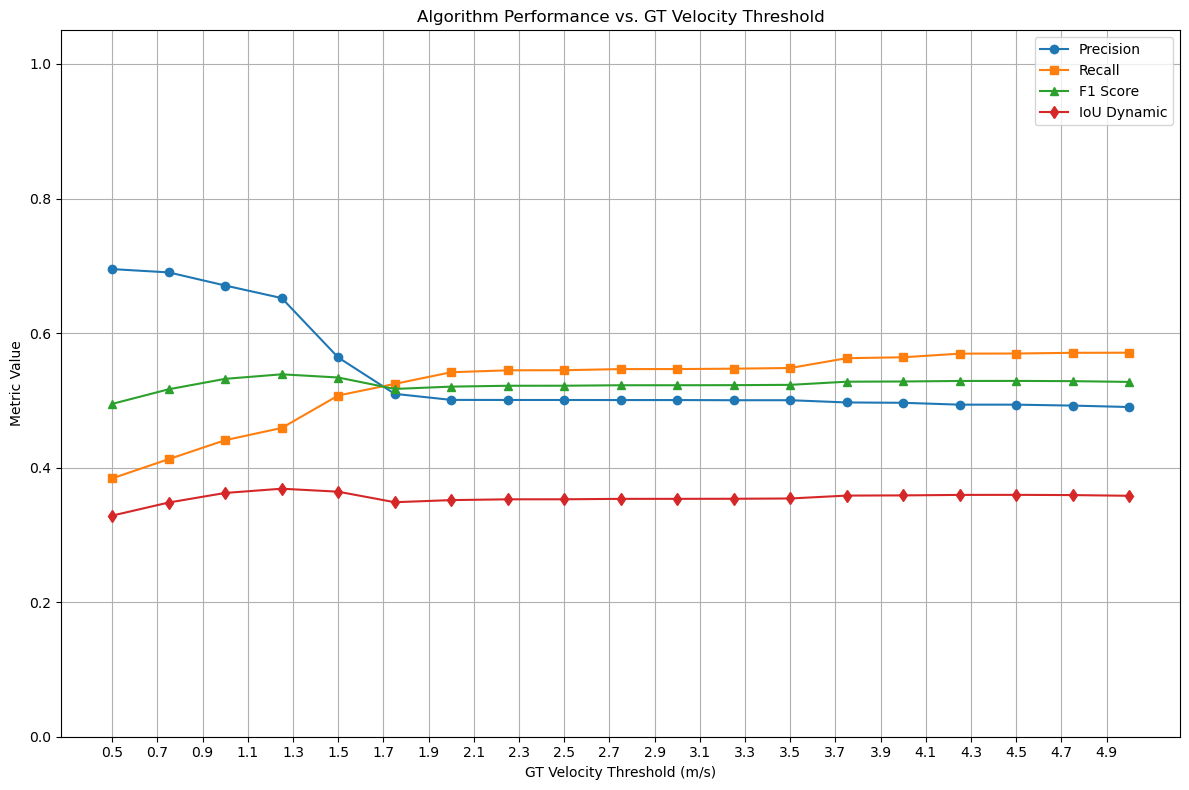


Cell 2: Metrics Plotting - OK


In [4]:

# --- Plotting the metrics ---
plt.figure(figsize=(12, 8)) # Adjust figure size as needed

plt.plot(gt_velocity_thresholds, precisions, marker='o', linestyle='-', label='Precision')
plt.plot(gt_velocity_thresholds, recalls, marker='s', linestyle='-', label='Recall')
plt.plot(gt_velocity_thresholds, f1_scores, marker='^', linestyle='-', label='F1 Score')
plt.plot(gt_velocity_thresholds, ious_dynamic, marker='d', linestyle='-', label='IoU Dynamic')

plt.title('Algorithm Performance vs. GT Velocity Threshold')
plt.xlabel('GT Velocity Threshold (m/s)')
plt.ylabel('Metric Value')
plt.legend() # Show legend to identify lines
plt.grid(True) # Add a grid for easier reading
plt.ylim(0, 1.05) # Set y-axis limits, typically metrics are between 0 and 1
plt.xticks(np.arange(min(gt_velocity_thresholds), max(gt_velocity_thresholds)+0.1, 0.2)) # Adjust x-axis ticks for clarity
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("\nCell 2: Metrics Plotting - OK")

In [ ]:
# %% Cell 3: Generate and Plot ROC and Precision-Recall Curves

# --- Parameters for ROC/PR Curve Generation ---
gt_velocity_thresholds_for_curves = np.linspace(0.1, 2.0, 20).tolist() 
eval_params_for_curves = base_eval_params.copy() 

print(f"\nGenerating data for ROC and Precision-Recall curves...")
print(f"  Sweeping GT Velocity Thresholds from {min(gt_velocity_thresholds_for_curves):.2f} to {max(gt_velocity_thresholds_for_curves):.2f} m/s.")

roc_pr_data_hdf5 = generate_roc_pr_data_gt_velocity_variant_hdf5(
    mdet_experiment_dir=MDET_EXPERIMENT_DIR_HDF5,
    gt_labels_base_dir=GT_LABELS_BASE_DIR_HDF5,
    gt_velocity_thresholds_for_roc=gt_velocity_thresholds_for_curves,
    eval_params_base=eval_params_for_curves
)

if roc_pr_data_hdf5 and roc_pr_data_hdf5.get('precision') and roc_pr_data_hdf5.get('recall'):
    print("Data generation for curves complete.")
    
    fig_roc_pr, axes = plt.subplots(1, 2, figsize=(18, 7)) 

    # --- CORRECTED CALL for plot_roc_curve ---
    experiment_label_str = f"MDet Fixed OP" # Construct the label
    
    plot_roc_curve(
        roc_pr_data_hdf5['fpr'],     # Pass fpr_list as the first argument
        roc_pr_data_hdf5['tpr'],     # Pass tpr_list as the second argument
        experiment_label=experiment_label_str, # Use the 'experiment_label' keyword
        ax=axes[0]                   # Pass the axis
    )
    # If you want to customize the title from here, do it on the axis object:
    axes[0].set_title("ROC-like Curve (Varying GT Vel. Threshold)") 
    # The x and y labels are already set by your plot_roc_curve function.
    # axes[0].set_xlabel("False Positive Rate (Approx. based on varying GT)") # Already set in function
    # axes[0].set_ylabel("True Positive Rate (Recall)") # Already set in function

    # --- CORRECTED CALL for plot_precision_recall_curve ---
    plot_precision_recall_curve(
        roc_pr_data_hdf5['recall'],    # Pass recall_list as the first argument
        roc_pr_data_hdf5['precision'], # Pass precision_list as the second argument
        experiment_label=experiment_label_str, # Use the 'experiment_label' keyword
        ax=axes[1]                     # Pass the axis
    )
    # If you want to customize the title from here:
    axes[1].set_title("Precision-Recall Curve (Varying GT Vel. Threshold)")
    
    fig_roc_pr.suptitle(f"M-Detector Performance vs. Varied Ground Truth Dynamic Definition", fontsize=16)
    fig_roc_pr.tight_layout(rect=[0, 0.03, 1, 0.95]) 
    plt.show()

else:
    print("Failed to generate data for ROC/PR curves or data was empty.")
    if roc_pr_data_hdf5:
        print(f"  Returned data keys: {list(roc_pr_data_hdf5.keys())}")
        if not roc_pr_data_hdf5.get('precision'): print("    'precision' key missing or list empty.")
        if not roc_pr_data_hdf5.get('recall'): print("    'recall' key missing or list empty.")

print("\nCell 3: ROC/PR Curves - OK")